In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
weather_data = pd.read_csv(r'C:\Users\shobi\Documents\GitHub\Complete-Data-Analysis-Project\data\WeatherData.csv')

weather_data.head(10)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
5,1/1/2012 5:00,-1.4,-3.3,87,9,6.4,101.27,Fog
6,1/1/2012 6:00,-1.5,-3.1,89,7,6.4,101.29,Fog
7,1/1/2012 7:00,-1.4,-3.6,85,7,8.0,101.26,Fog
8,1/1/2012 8:00,-1.4,-3.6,85,9,8.0,101.23,Fog
9,1/1/2012 9:00,-1.3,-3.1,88,15,4.0,101.20,Fog


In [26]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [27]:
weather_data.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


In [28]:
print("Missing values :",weather_data.isnull().sum())

Missing values : Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


In [29]:
print( "Duplicated values :", weather_data.duplicated().sum())

Duplicated values : 0


In [30]:
weather_data.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

In [31]:
#Convert date
weather_data['Date/Time'] = pd.to_datetime(weather_data['Date/Time'])

In [32]:
#Unique weather types
print("Weather value counts :")
print(weather_data['Weather'].value_counts())

Weather value counts :
Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing 

In [33]:
#Monthly average temperature
weather_data['Month'] = weather_data['Date/Time'].dt.month
monthy_temp = weather_data.groupby('Month')['Temp_C'].mean()
print("Monthy temperature :")
print(monthy_temp)

Monthy temperature :
Month
1     -7.371505
2     -4.225000
3      3.121237
4      7.009306
5     16.237769
6     20.134028
7     22.790054
8     22.279301
9     16.484444
10    10.954973
11     0.931389
12    -3.306317
Name: Temp_C, dtype: float64


In [34]:
#Weather distribution
weather_counts = weather_data['Weather'].value_counts().head(5)
print("Weather Counts :")
print(weather_counts)

Weather Counts :
Weather
Mainly Clear     2106
Mostly Cloudy    2069
Cloudy           1728
Clear            1326
Snow              390
Name: count, dtype: int64


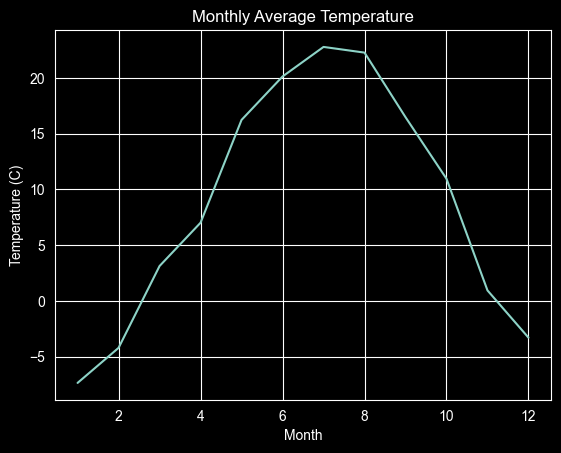

In [35]:
#Line chart - temperature trend
plt.figure()
monthy_temp.plot()
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (C)")
plt.savefig("visualizations/temp_trend.png")
plt.show()

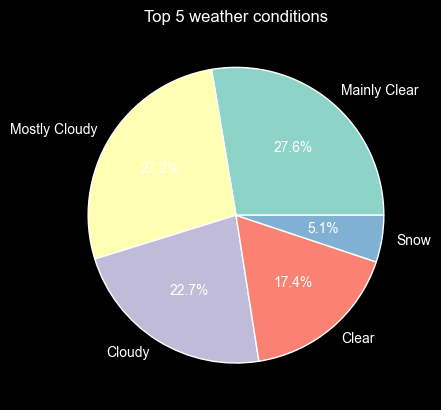

In [36]:
#Pie Chart – Weather Distribution
plt.figure()
weather_counts.plot(kind='pie',autopct='%1.1f%%')
plt.title("Top 5 weather conditions")
plt.ylabel("")
plt.savefig("visualizations/weather_distribution.png")
plt.show()


In [38]:
#Bar Chart – Wind Speed by Weather
wind_avg = weather_counts.groupby('Weather')['Wind Speed_km/h'].mean().head(5)
plt.figure()
wind_avg.plot(kind='bar')
plt.title("Average Wind Speed by Weather")
plt.xlabel("Weather")
plt.ylabel("Wind Speed (km/h)")
plt.savefig("visualizations/wind_distribution.png")
plt.show()

KeyError: 'Column not found: Wind Speed_km/h'

In [39]:
weather_data['Wind Speed_km/h']

0        4
1        4
2        7
3        6
4        7
        ..
8779    30
8780    24
8781    28
8782    28
8783    30
Name: Wind Speed_km/h, Length: 8784, dtype: int64